## 1. Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import umap
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from datasets import load_dataset
from collections import Counter, defaultdict

## 2. Paths and basic config

In [ ]:
IMAGENET_DIR = "Maysee/tiny-imagenet"
NUM_WORKERS = 8
BATCH_SIZE = 128
MAX_SAMPLES_FOR_HEAVY_EDA = 50000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

##3. Load Datasets

In [ ]:
train_ds = load_dataset(IMAGENET_DIR, split="train")
val_ds   = load_dataset(IMAGENET_DIR, split="valid")

# Standard ImageNet transforms
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Apply transforms
def apply_transform(example):
    example["pixel_values"] = transform(example["image"])
    return example

train_ds = train_ds.with_transform(apply_transform)
val_ds   = val_ds.with_transform(apply_transform)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…):   0%|          | 0.00/146M [00:00<?, ?B/s]

data/valid-00000-of-00001-70d52db3c749a9(…):   0%|          | 0.00/14.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Device:", DEVICE)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

num_classes = train_ds.features["label"].num_classes
class_names = train_ds.features["label"].names
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for i, name in enumerate(class_names)}

print("Num classes:", num_classes)
print("First 10 classes:", class_names[:10])

Train batches: 782
Val batches: 79
Device: cuda
Train size: 100000
Val size: 10000
Num classes: 200
First 10 classes: ['n01443537', 'n01629819', 'n01641577', 'n01644900', 'n01698640', 'n01742172', 'n01768244', 'n01770393', 'n01774384', 'n01774750']


## 4. Class Distribution

In [ ]:
train_ds = load_dataset(IMAGENET_DIR, split="train")
val_ds   = load_dataset(IMAGENET_DIR, split="valid")

In [ ]:
# Extract labels
train_labels = [example["label"] for example in train_ds]
val_labels   = [example["label"] for example in val_ds]

train_counts = Counter(train_labels)
val_counts   = Counter(val_labels)

print("Num classes:", train_ds.features["label"].num_classes)
print("Train class distribution (first 10):", list(train_counts.items())[:10])
print("Val class distribution (first 10):", list(val_counts.items())[:10])

Num classes: 200
Train class distribution (first 10): [(0, 500), (1, 500), (2, 500), (3, 500), (4, 500), (5, 500), (6, 500), (7, 500), (8, 500), (9, 500)]
Val class distribution (first 10): [(0, 50), (1, 50), (2, 50), (3, 50), (4, 50), (5, 50), (6, 50), (7, 50), (8, 50), (9, 50)]


## 5. Image resolution and aspect ratio

In [ ]:
def sample_indices(dataset, max_samples):
    n = len(dataset)
    if max_samples is None or max_samples >= n:
        return list(range(n))
    return random.sample(range(n), max_samples)

train_indices_res = sample_indices(train_ds, MAX_SAMPLES_FOR_HEAVY_EDA)

widths, heights, aspect_ratios = [], [], []

for idx in tqdm(train_indices_res, desc="Scanning resolutions"):
    example = train_ds[idx]
    img = example["image"]          # <-- Already a PIL Image
    img = img.convert("RGB")
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspect_ratios.append(w / h)

res_df = pd.DataFrame({
    "width": widths,
    "height": heights,
    "aspect_ratio": aspect_ratios
})

Scanning resolutions: 100%|██████████| 50000/50000 [00:12<00:00, 4067.26it/s]


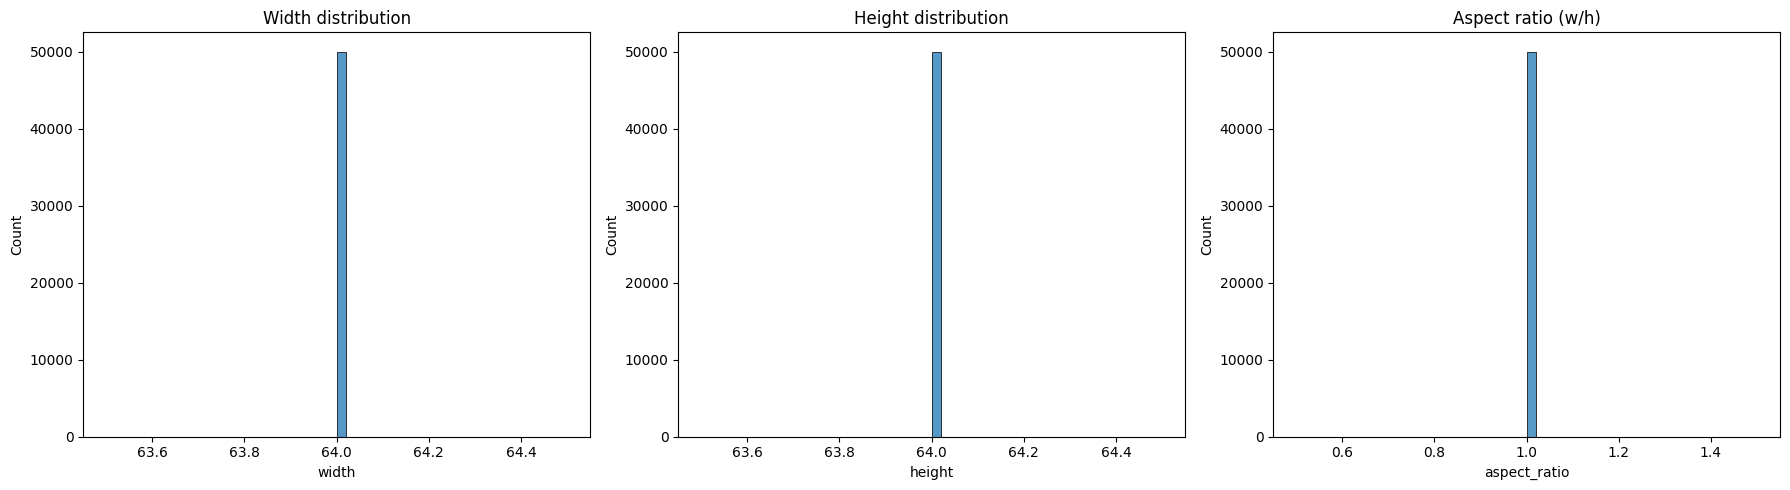

         width   height  aspect_ratio
count  50000.0  50000.0       50000.0
mean      64.0     64.0           1.0
std        0.0      0.0           0.0
min       64.0     64.0           1.0
25%       64.0     64.0           1.0
50%       64.0     64.0           1.0
75%       64.0     64.0           1.0
max       64.0     64.0           1.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(res_df["width"], bins=50, ax=axes[0])
axes[0].set_title("Width distribution")

sns.histplot(res_df["height"], bins=50, ax=axes[1])
axes[1].set_title("Height distribution")

sns.histplot(res_df["aspect_ratio"], bins=50, ax=axes[2])
axes[2].set_title("Aspect ratio (w/h)")

plt.tight_layout()
plt.show()

print(res_df.describe())

## 6. Sample Visualization Per Class

In [ ]:
class_names = train_ds.features["label"].names
num_classes = len(class_names)
from collections import defaultdict

class_to_indices = defaultdict(list)

for idx, example in enumerate(train_ds):
    class_to_indices[example["label"]].append(idx)

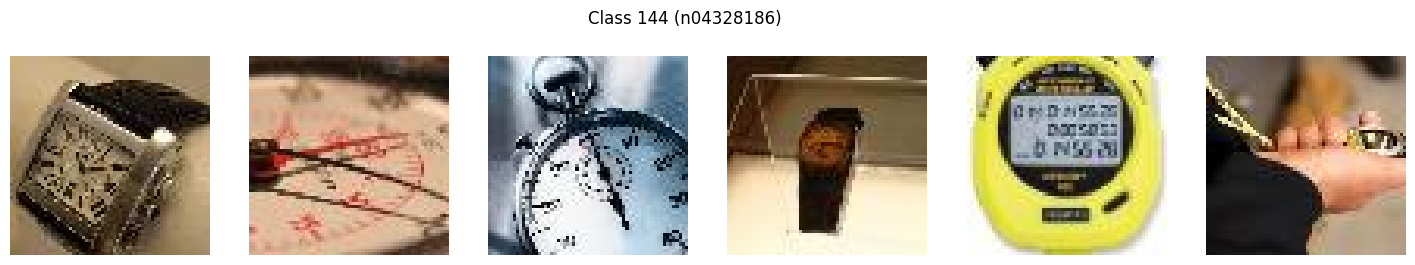

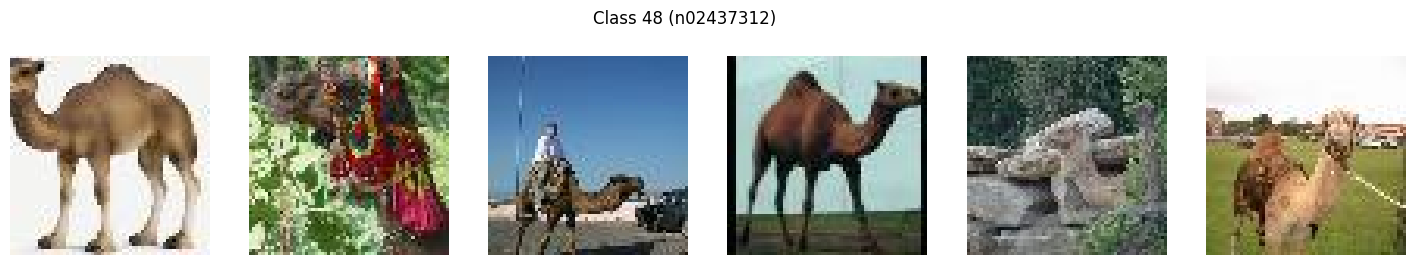

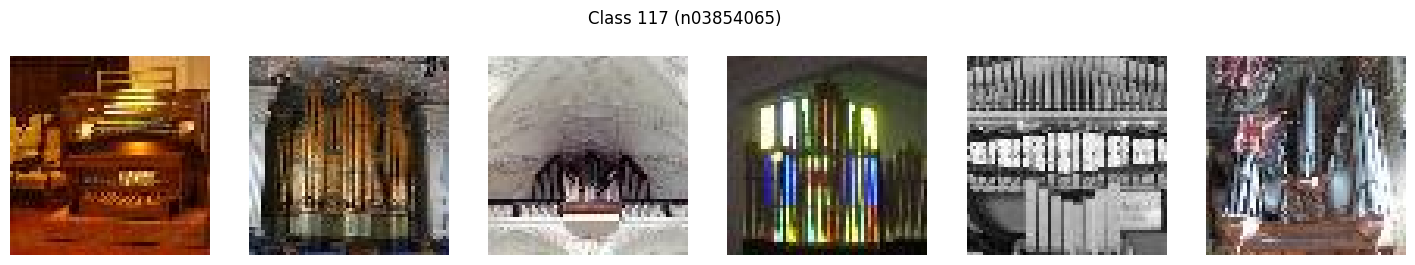

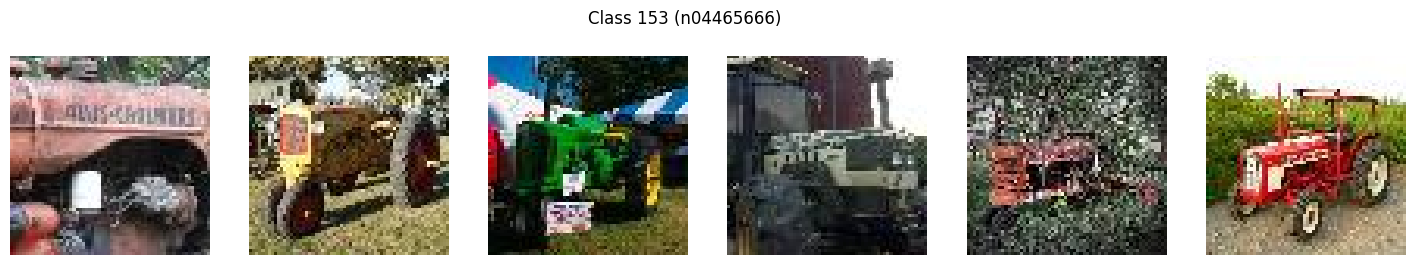

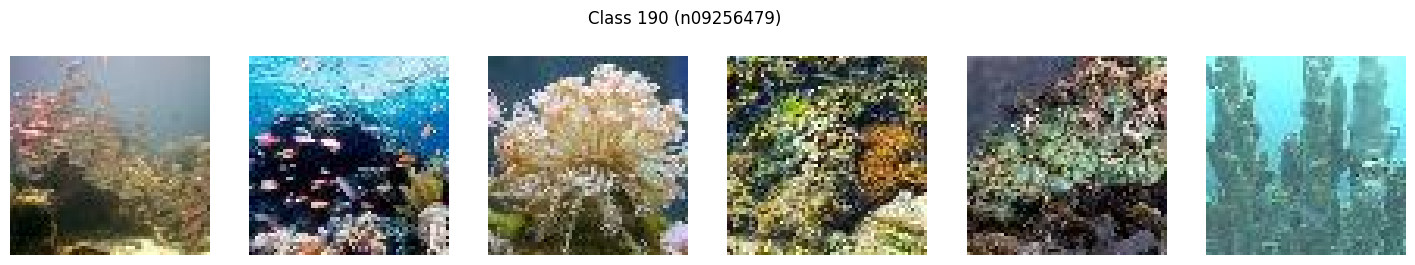

In [ ]:
def show_samples_for_class(class_idx, n=8):
    indices = class_to_indices[class_idx]
    sample_indices = random.sample(indices, min(n, len(indices)))

    fig, axes = plt.subplots(1, len(sample_indices), figsize=(3 * len(sample_indices), 3))
    if len(sample_indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_indices):
        img = train_ds[idx]["image"].convert("RGB")
        ax.imshow(img)
        ax.axis("off")

    plt.suptitle(f"Class {class_idx} ({class_names[class_idx]})")
    plt.show()

for class_idx in random.sample(range(num_classes), 5):
    show_samples_for_class(class_idx, n=6)

##7. Embedding-based EDA with a pretrained model

In [ ]:
class EmbedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        example = self.base_dataset[idx]

        img = example["image"]
        label = example["label"]

        img = img.convert("RGB")
        img = self.transform(img)

        return img, label

In [ ]:
# Use a pretrained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model = model.to(DEVICE)
model.eval()

# Remove final classifier to get embeddings
embedding_model = torch.nn.Sequential(*list(model.children())[:-1]).to(DEVICE)

transform_embed = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

embed_indices = sample_indices(train_ds, 20000)

embed_dataset = EmbedDataset(train_ds, embed_indices, transform_embed)

embed_loader = DataLoader(
    embed_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

all_embeds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(embed_loader, desc="Extracting embeddings"):
        imgs = imgs.to(DEVICE)
        feats = embedding_model(imgs)      # [B, 2048, 1, 1]
        feats = feats.view(feats.size(0), -1).cpu()
        all_embeds.append(feats)
        all_labels.append(labels)

all_embeds = torch.cat(all_embeds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print("Embeddings shape:", all_embeds.shape)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]
Extracting embeddings: 100%|██████████| 157/157 [00:35<00:00,  4.39it/s]

Embeddings shape: (20000, 2048)


## 9. 2D visualization (UMAP or t-SNE)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


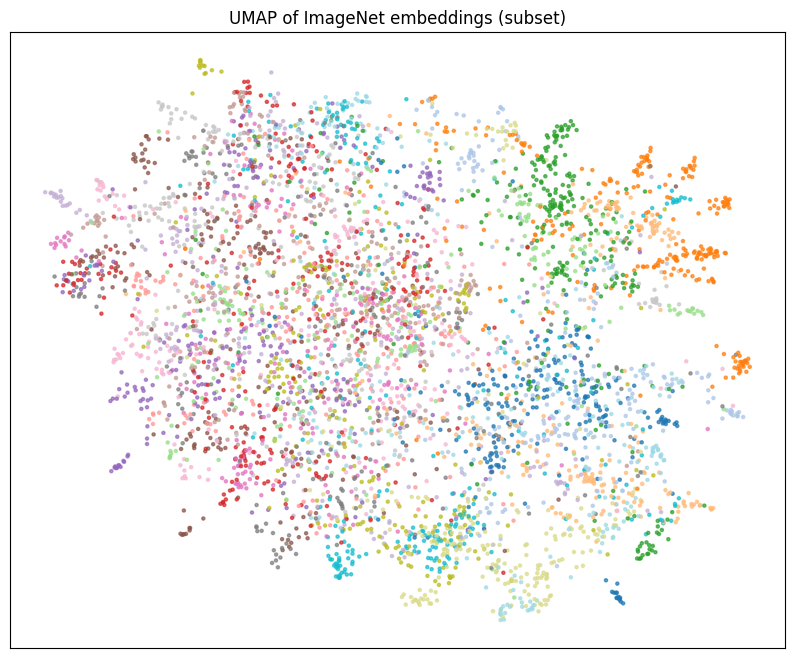

In [ ]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, metric="cosine", random_state=42)
embeds_2d = reducer.fit_transform(all_embeds)

# For visualization
vis_indices = np.random.choice(len(embeds_2d), size=5000, replace=False)
x = embeds_2d[vis_indices, 0]
y = embeds_2d[vis_indices, 1]
labels_vis = all_labels[vis_indices]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=labels_vis, cmap="tab20", s=5, alpha=0.7)
plt.title("UMAP of ImageNet embeddings (subset)")
plt.xticks([])
plt.yticks([])
plt.show()